In [1]:
import numpy as np
from dnnlpy.optim import rmsprop
from torch import Tensor, overrides
from torch.distributed import optim
from torchgen.utils import concatMap

"""
    问题: Adagrad ,st 越来越大,有效的学习率只会越来越小
    解决:
        不在使用历完整的历史的平方梯度累计和,使用指数滑动平均来记录一段时间的梯度尺度
"""

from collections.abc import Iterable
from typing import List, Any

import torch
import torch.nn as nn
import torch.nn.functional as F
import dnnlpy
import dnnlpy.optim as dopt
import matplotlib.pyplot as plt

dnnlpy.set_matplotlib_format('svg')

print("PyTorch version", torch.__version__)



PyTorch version 2.13.0+cpu


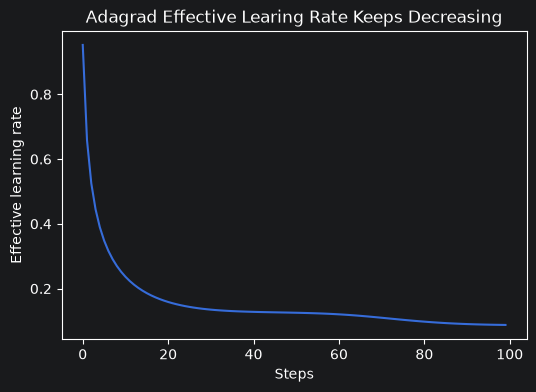

In [3]:
"""
Adagrad的问题: 历史记忆太长
"""
num_steps = 100
initial_lr = 1.0
eps = 1e-10

simulated_grad = torch.arange(1, num_steps + 1, dtype=torch.float32)
simulated_grad = 1.0 + 0.5 * (simulated_grad / 10.0).sin()

sum_of_sq_grad = torch.tensor(0.0)
adagrad_lr_history = []

for grad in simulated_grad:
    sum_of_sq_grad += grad.square()
    lr = initial_lr / (sum_of_sq_grad.sqrt() + eps)
    adagrad_lr_history.append(lr.item())

fig = plt.figure(1, figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(adagrad_lr_history)
ax.set_xlabel('Steps')
ax.set_ylabel('Effective learning rate')
ax.set_title('Adagrad Effective Learing Rate Keeps Decreasing')
plt.show()


In [ ]:
"""
从累计和到滑动平均
    不要累计全部历史,而是一段时间的梯度尺度
"""


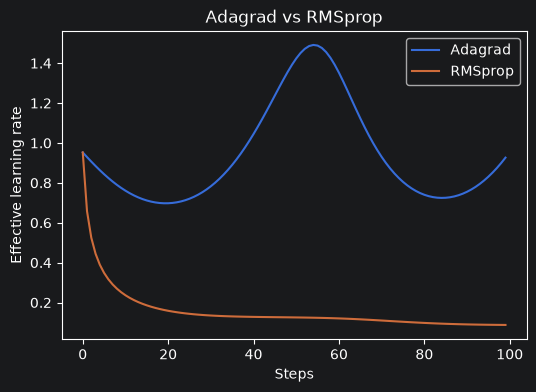

In [4]:
"""
RMSprop: 用滑动平均估计梯度尺度
"""
rho = 0.9
velocity = torch.tensor(0.0)
rmsprop_lr_history = []

for t, grad in enumerate(simulated_grad, start=1):
    velocity = rho * velocity + (1 - rho) * grad.square()
    velocity_adj = velocity / (1 - pow(rho, t))
    lr = initial_lr / (velocity_adj.sqrt() + eps)
    rmsprop_lr_history.append(lr.item())

fig = plt.figure(2, figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(rmsprop_lr_history)
ax.plot(adagrad_lr_history)
ax.set_xlabel('Steps')
ax.set_ylabel('Effective learning rate')
ax.legend(['Adagrad', 'RMSprop'])
ax.set_title('Adagrad vs RMSprop')
plt.show()



In [5]:
from typing import override

"""
RMSprop的Pytorch的实现
"""


class RMSprop(dopt.Optimizer):
    def __init__(self, params: Iterable[Tensor], lr: float = 0.1, rho: float = 0.9, eps: float = 1e-8,
                 weight_decay: float = 0.0, momentum: float = 0.0):
        super().__init__(params)
        self.lr = lr
        self.rho = rho
        self.eps = eps
        self.weight_decay = weight_decay
        self.momentum = momentum
        self.ema_of_sq_grad = [torch.zeros_like(p) for p in self.params]
        self.momentum_buffer = [torch.zeros_like(p) for p in self.params]

    @override
    @torch.no_grad()
    def step(self):
        for p, v, buffer in zip(self.params, self.ema_of_sq_grad, self.momentum_buffer, strict=True):
            if p.grad is None:
                continue
            grad = p.grad
            if self.weight_decay > 0:
                grad = grad.add(grad.square(), alpha=self.weight_decay)
            v.mul_(self.rho).add_(grad.square(), alpha=1 - self.rho)

            if self.momentum > 0:
                buffer.mul_(self.momentum).addcdiv_(grad, v.sqrt() + self.eps)
                p.sub_(buffer, alpha=self.lr)
            else:
                p.addcdiv(grad, v.sqrt() + self.eps, value=-self.lr)

    @torch.no_grad()
    def get_effective_lr(self) -> list[Tensor]:
        effective_lr = []
        for v in self.ema_of_sq_grad:
            lr = self.lr / (v.sqrt() + self.eps).clone()
            effective_lr.append(lr)
        return effective_lr




In [6]:
"""
Adadelta 的Pytorch的实现
    - square_avgs: 梯度平方的滑动平均
    - accumulate_updates: 更新平方的滑动平均
"""


class Adadelta(dopt.Optimizer):
    def __init__(self, params: Iterable[Tensor], lr: float = 0.1, rho: float = 0.9, eps: float = 1e-6,
                 weight_decay: float = 0.0):
        super().__init__(params)
        self.lr = lr
        self.rho = rho
        self.eps = eps
        self.weight_decay = weight_decay
        self.ema_of_sq_grad = [torch.zeros_like(p) for p in self.params]
        self.ema_of_sq_update = [torch.zeros_like(p) for p in self.params]

    @override
    @torch.no_grad()
    def step(self):
        for p, v, u in zip(self.params, self.ema_of_sq_grad, self.ema_of_sq_update, strict=True):
            if p.grad is None:
                continue
            grad = p.grad
            if self.weight_decay > 0:
                grad = grad.add_(p, alpha=self.weight_decay)
            v.mul_(self.rho).add_(grad.square(), alpha=1 - self.rho)
            delta_x = (u + self.eps).sqrt() / (v + self.eps).sqrt() * grad

            u.mul_(self.rho).add_(delta_x, alpha=1 - self.rho)
            p.sub_(delta_x, alpha=self.lr)

    @torch.no_grad()
    def get_effective_lr(self) -> list[Tensor]:
        effective_lr = []
        for r, u in zip(
                self.ema_of_sq_grad, self.ema_of_sq_update, strict=True
        ):
            lr = self.lr * (u + self.eps).sqrt() / (v + self.eps).sqrt()
            effective_lr.append(lr)
        return effective_lr




In [ ]:
"""
RMSprop 和Adadelta的关系
    - adagrad: 把完整的历史平方的梯度调整到每个参数的学习率中
    - rmsprop:把adagrad的完整的历史平方改成滑动平均,避免学习率持续衰减
    - adadelta: 把rmsprop的基础上一部引入了更新量的尺寸,减少对全局学习参数的依赖
"""


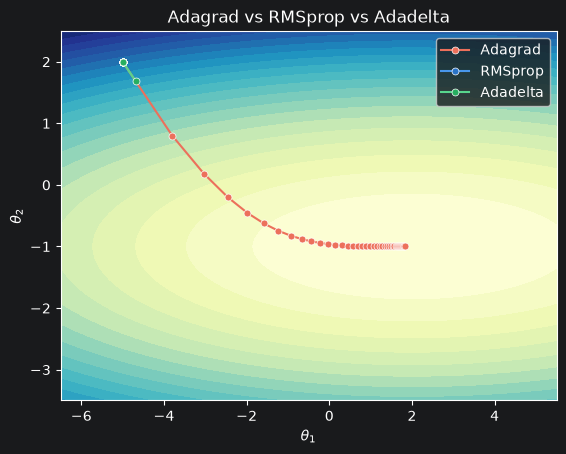

In [10]:
"""
    一个小实验:比较几种优化器
"""


def loss_fn(theta: Tensor) -> Tensor:
    x, y = theta[0], theta[1]
    return 0.1 * (x - 2) ** 2 + 2 * (y + 1) ** 2


theta1 = torch.tensor([-5.0, 2.0], requires_grad=True)
theta2 = torch.tensor([-5.0, 2.0], requires_grad=True)
theta3 = torch.tensor([-5.0, 2.0], requires_grad=True)

optimizer1 = dopt.Adagrad([theta1], lr=1.2)
optimizer2 = RMSprop([theta2], lr=0.5, rho=0.9)
optimizer3 = Adadelta([theta3], lr=100, rho=0.9)

adagrad_history = dopt.run_optimizer(optimizer1, loss_fn, steps=40)
rmsprop_history = dopt.run_optimizer(optimizer2, loss_fn, steps=40)
adadelta_history = dopt.run_optimizer(optimizer3, loss_fn, steps=40)

x = torch.linspace(-6.5, 5.5, 200)
y = torch.linspace(-3.5, 2.5, 200)
X, Y = torch.meshgrid(x, y, indexing='ij')

Z = 0.1 * (X - 2) ** 2 + 2 * (Y + 1) ** 2

fig = plt.figure(3)
ax = fig.add_subplot(1, 1, 1)
ax.contourf(X, Y, Z, levels=25, cmap='YlGnBu')
common_kwargs = dict(
    marker='o',
    markersize=5,
    markeredgecolor='white',
    markeredgewidth=0.5,
)

ax.plot(

    adagrad_history[:,0],
    adagrad_history[:,1],
    color='#EC705B',
    markerfacecolor='#EC705B',
    **common_kwargs
)

ax.plot(
    rmsprop_history[:,0],
    rmsprop_history[:,1],
    color='#4896EB',
    markerfacecolor='#2A74C8',
    **common_kwargs
)
ax.plot(
    adadelta_history[:,0],
    adadelta_history[:,1],
    color='#58D68D',
    markerfacecolor='#27AE60',
    **common_kwargs
)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.legend(['Adagrad', 'RMSprop', 'Adadelta'])
ax.set_title('Adagrad vs RMSprop vs Adadelta')
plt.show()